# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [1]:
import multiprocessing

from collections import Counter
from typing import Type
from joblib import Parallel, delayed

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, confusion_matrix, davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state

from scipy.optimize import linear_sum_assignment

from umap import UMAP

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad, io, gzip, os

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

from pathlib import Path

In [2]:
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
RADNDOM_SEED = 42

In [3]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [5]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

`align_labels` aligns arbitrary cluster labels to a set of reference labels by maximizing agreement via the Hungarian algorithm. This is useful because clustering algorithms assign label IDs arbitrarily, and direct comparison to true labels requires a permutation alignment.

**Inputs**
- `true_labels` (`np.ndarray`): Ground-truth labels for each sample (preferably integer-coded, e.g., `pd.Categorical(...).codes`).
- `pred_labels` (`np.ndarray`): Predicted cluster labels for each sample (arbitrary IDs).

**Process**
1. Computes the confusion matrix `cm` between `true_labels` and `pred_labels`.
2. Applies the Hungarian algorithm (`linear_sum_assignment`) to `-cm` to find the permutation of predicted labels that maximizes total matches.
3. Builds a mapping from predicted labels to matched true labels.
4. Re-labels `pred_labels` according to this mapping; any predicted label not present in the mapping is left unchanged.

**Output**
- `np.ndarray`: Aligned predicted labels with IDs permuted to best match `true_labels` (same shape as `pred_labels`).

In [6]:
def align_labels(true_labels, pred_labels):
    """
    Aligns predicted cluster labels to true labels by maximizing agreement using the Hungarian algorithm.

    Args:
        true_labels (np.ndarray): Ground-truth labels for each sample (integer-coded).
        pred_labels (np.ndarray): Predicted cluster labels for each sample (arbitrary IDs).

    Returns:
        np.ndarray: Aligned predicted labels with IDs permuted to best match true_labels.
    """
    cm = confusion_matrix(true_labels, pred_labels)
    
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    label_map = {old: new for old, new in zip(col_ind, row_ind)}
    return np.array([label_map[l] if l in label_map else l for l in pred_labels])

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [7]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric, squared=True)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, random_state: int) -> np.ndarray:
    """
    Generates a reference (null) dataset by sampling each feature independently
    from a uniform distribution spanning the observed feature range.

    Args:
        X (np.ndarray): Original dataset.
        random_state (int): Seed for reproducibility.

    Returns:
        np.ndarray: Null (reference) dataset of same shape as X.
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the Gap Statistic for a clustering solution, comparing observed within-cluster dispersion
    to that expected under a null reference distribution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').
        n_refs (int): Number of reference datasets to generate (default: 10).
        algorithm (Type[ClusterMixin]): Clustering algorithm used for reference clustering (default: KMeans).
        random_state (str or None): Random seed for reproducibility.

    Returns:
        float: Computed Gap Statistic value for the given clustering configuration.
    """
    num_cores = N_JOBS
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k)
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into

$$
\frac{1}{1 + \textit{Davies–Bouldin Index}}
$$

, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [8]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

---

## 1. Pre-Process the Data

In [9]:
DATA_DIR = Path("../data/klein")  # change if needed
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [10]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [11]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [12]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [13]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs; no log yet

print(adata)
print(adata.obs["condition"].value_counts())

AnnData object with n_obs × n_vars = 2717 × 24175
    obs: 'condition'
    layers: 'counts'
condition
d0    933
d7    798
d4    683
d2    303
Name: count, dtype: int64


write for reuse:

---

## 2. Analyse Data

### 2.1 Plot PCA Reduced Data Set:

In [14]:
print(f"np.unique(obs): {np.unique(adata.obs['condition'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['condition'].values)))}")

np.unique(obs): ['d0' 'd2' 'd4' 'd7']
len(np.unique(obs)): 4


In [15]:
# extract X (cells × genes) from AnnData into a pandas DataFrame
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
y = adata.obs['condition'].values
print("X.shape:", X.shape)

X.shape: (2717, 24175)


In [16]:
y.shape

(2717,)

PCA plot of raw gene counts:

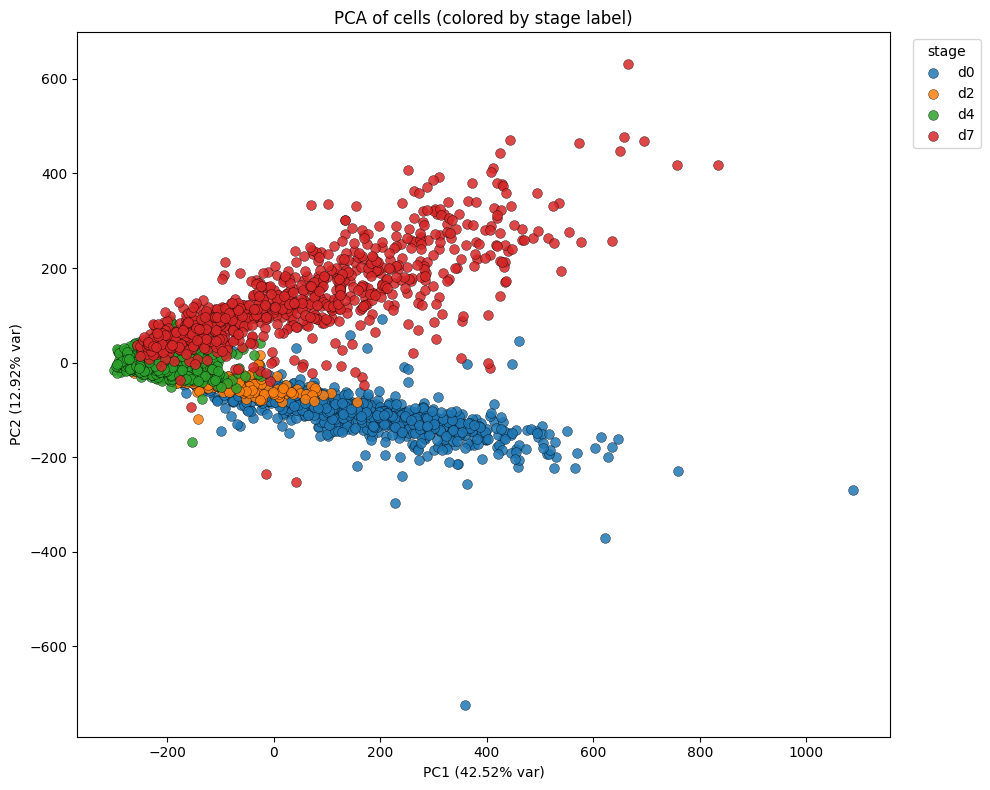

In [17]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Select top 2,000 HVGs:

Normalize and Select Highly-Variable Genes:

In [18]:
print(adata.obs.columns)

Index(['condition'], dtype='object')


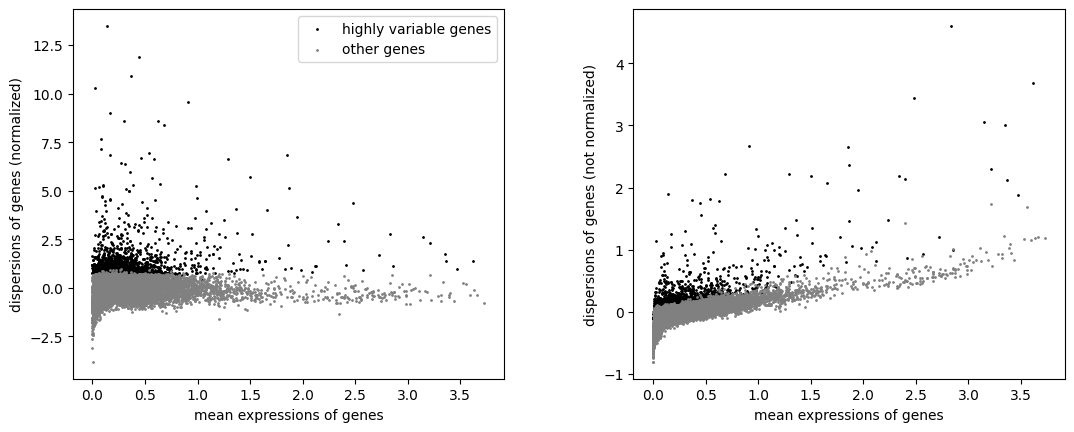

In [19]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="condition", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [20]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [21]:
# Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (2717, 2000)
y.shape: (2717,)


PCA of log1p transformed 2000 HVGs:

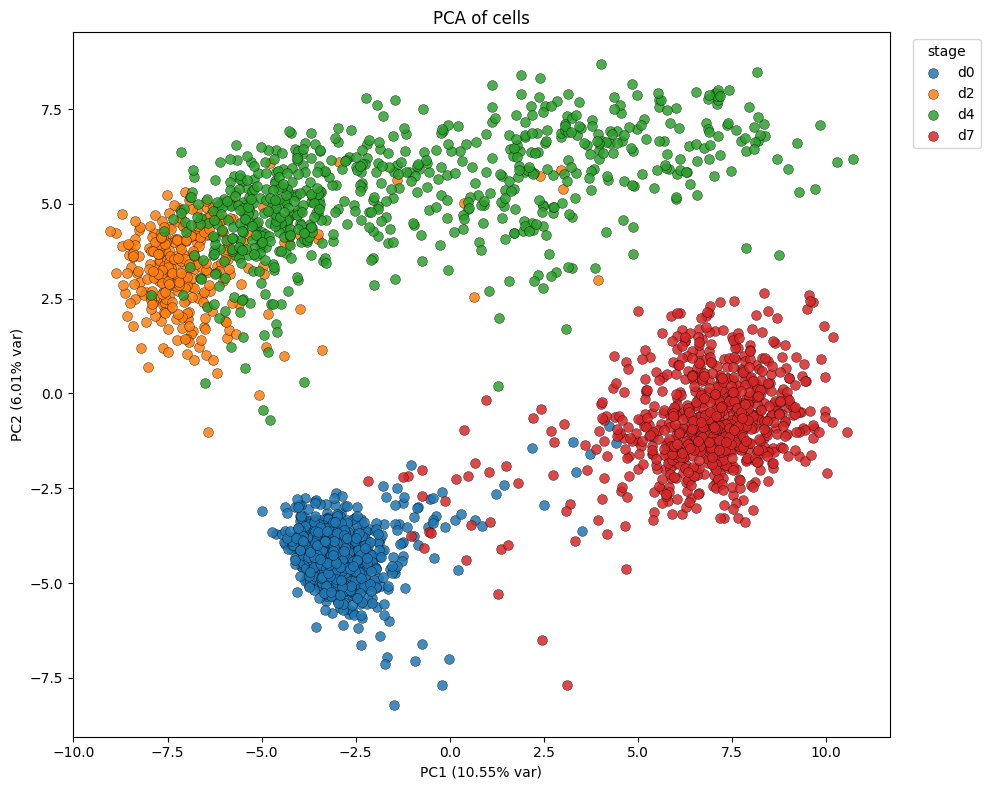

In [22]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.# Perform PCA to 50 PCs (analogous to scMINER):

scMINER selects top 2000 HVGs and then applies PCA to obtain 50 PCs. We will follow this same preprocessing steps.

In [ ]:
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X)
print("X_pca_50 shape:", X_pca_50.shape)

X_pca_50 shape: (2717, 50)


### 2.4 Perform Clustering with "Oracle" Number of Clusters:

In [ ]:
y_true = adata.obs['condition'].values
n_clusters = len(pd.Categorical(y_true).categories)

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RADNDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_pca_50)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)

# Agglomerative (Ward linkage)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X_pca_50)
ari_agg = adjusted_rand_score(y_true, agg_labels)

# Leiden
leiden = LeidenClustering(n_clusters=n_clusters, random_state=RADNDOM_SEED)
leiden_labels = leiden.fit_predict(X_pca_50)
ari_leiden = adjusted_rand_score(y_true, leiden_labels)

# Spectral Clustering (median heuristic for gamma)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=RADNDOM_SEED)  # subsampling because pairwise distances computation is expensive: O(n^2 * d)
idx = next(sss.split(np.arange(len(y_true)), y_true))[1]
dists = pairwise_distances(X_pca_50[idx], metric='sqeuclidean')
median_dist = np.median(dists)
gamma = 1.0 / (2 * median_dist ** 2)
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=gamma, random_state=RADNDOM_SEED)
spectral_labels = spectral.fit_predict(X_pca_50)
ari_spectral = adjusted_rand_score(y_true, spectral_labels)

print(f"ARI KMeans: {ari_kmeans:.4f}")
print(f"ARI Agglomerative (Ward): {ari_agg:.4f}")
print(f"ARI Leiden: {ari_leiden:.4f}")
print(f"ARI Spectral (gamma={gamma:.6f}): {ari_spectral:.4f}")

ARI KMeans: 0.3243
ARI Agglomerative (Ward): 0.7936
ARI Leiden: 0.4995
ARI Spectral (gamma=0.000002): 0.7173


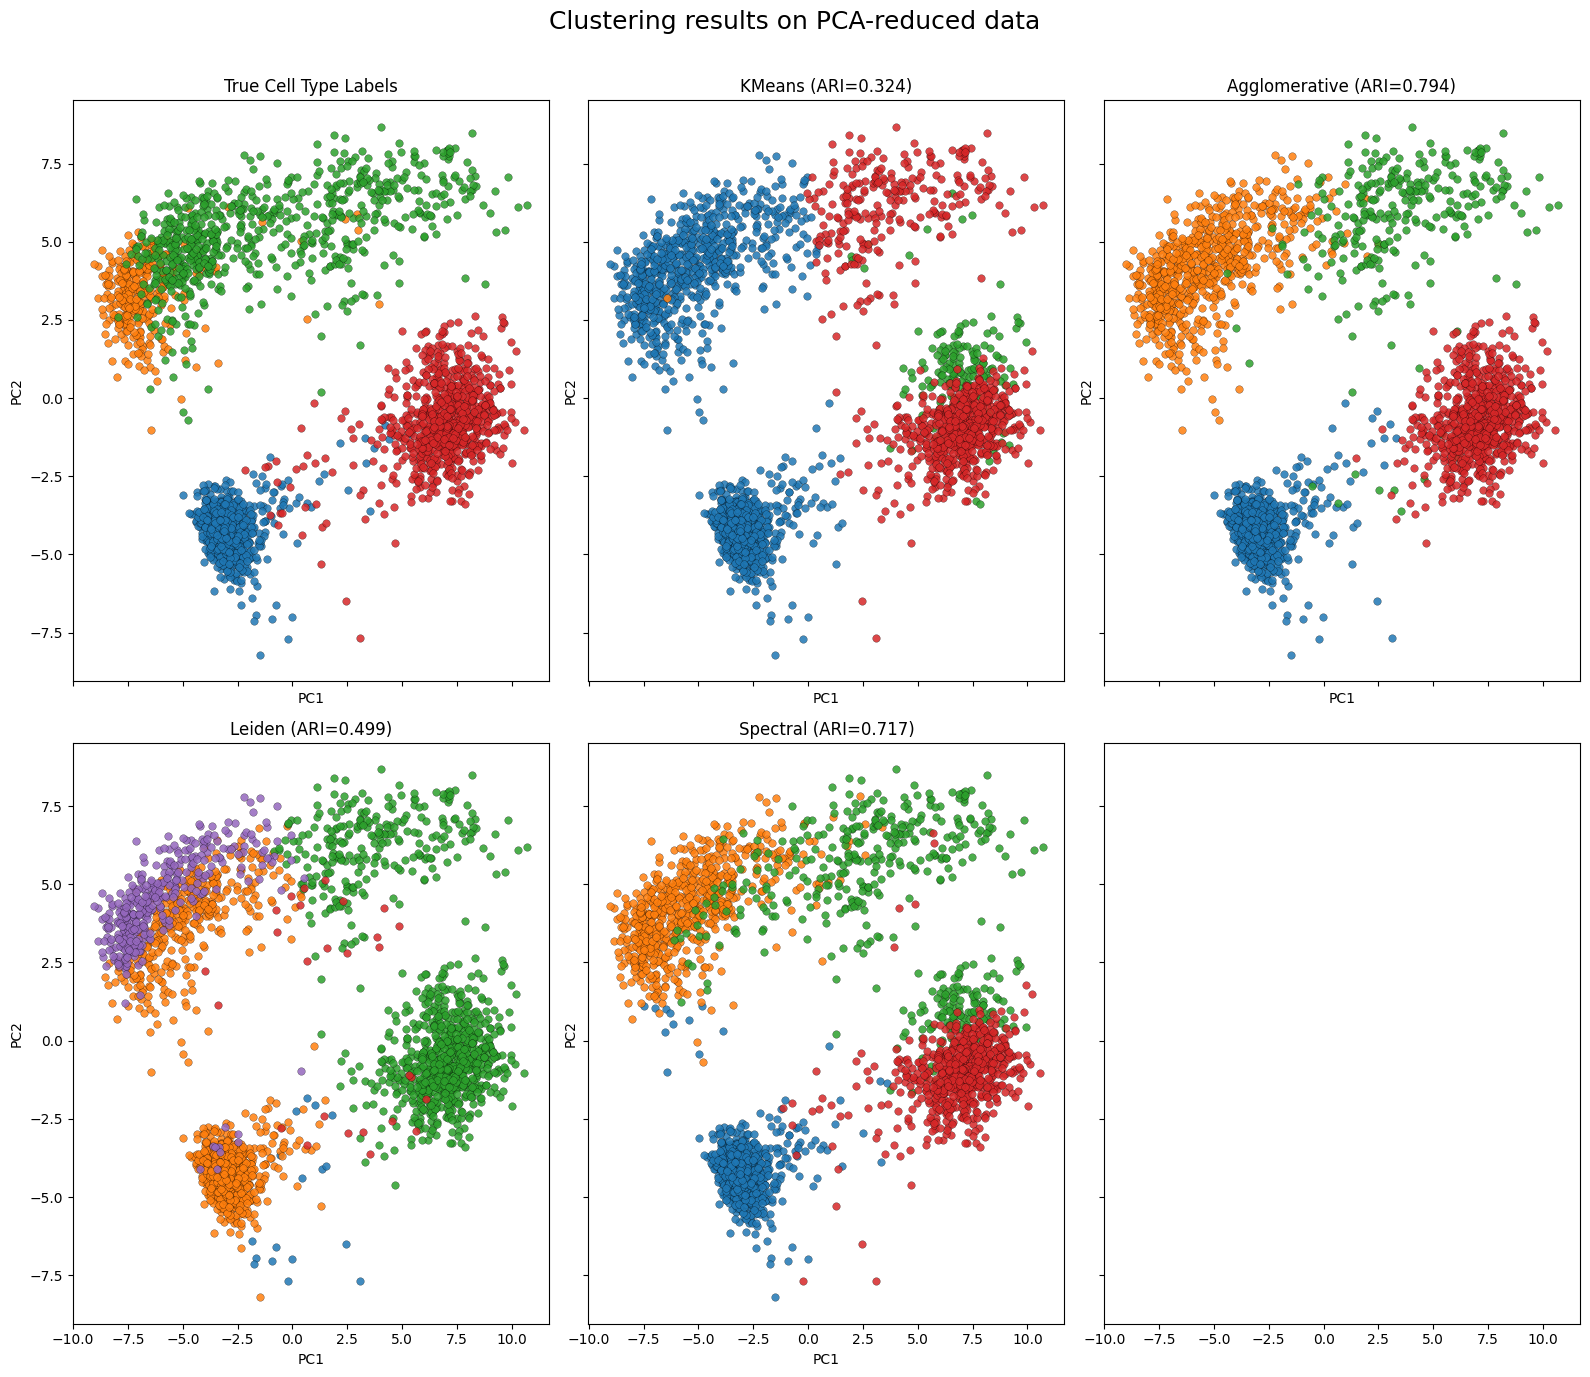

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 14), sharex=True, sharey=True)

# Plot true labels
pc_df['label'] = y
ax_true = axes[0, 0]
for lab in pd.Categorical(y_true).categories:
    sel = pc_df['label'] == lab
    ax_true.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=lab)
ax_true.set_title("True Cell Type Labels")
ax_true.set_xlabel("PC1")
ax_true.set_ylabel("PC2")
# ax_true.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

titles = [
    f"KMeans (ARI={ari_kmeans:.3f})",
    f"Agglomerative (ARI={ari_agg:.3f})",
    f"Leiden (ARI={ari_leiden:.3f})",
    f"Spectral (ARI={ari_spectral:.3f})"
]
clusterings = [kmeans_labels, agg_labels, leiden_labels, spectral_labels]
aligned_clusterings = [align_labels(pd.Categorical(y_true).codes, labels) for labels in clusterings]

for ax, labels, title in zip(axes.flat[1:], aligned_clusterings, titles):
    for cluster in np.unique(labels):
        sel = labels == cluster
        ax.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=f"Cluster {cluster}")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle("Clustering results on PCA-reduced data", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

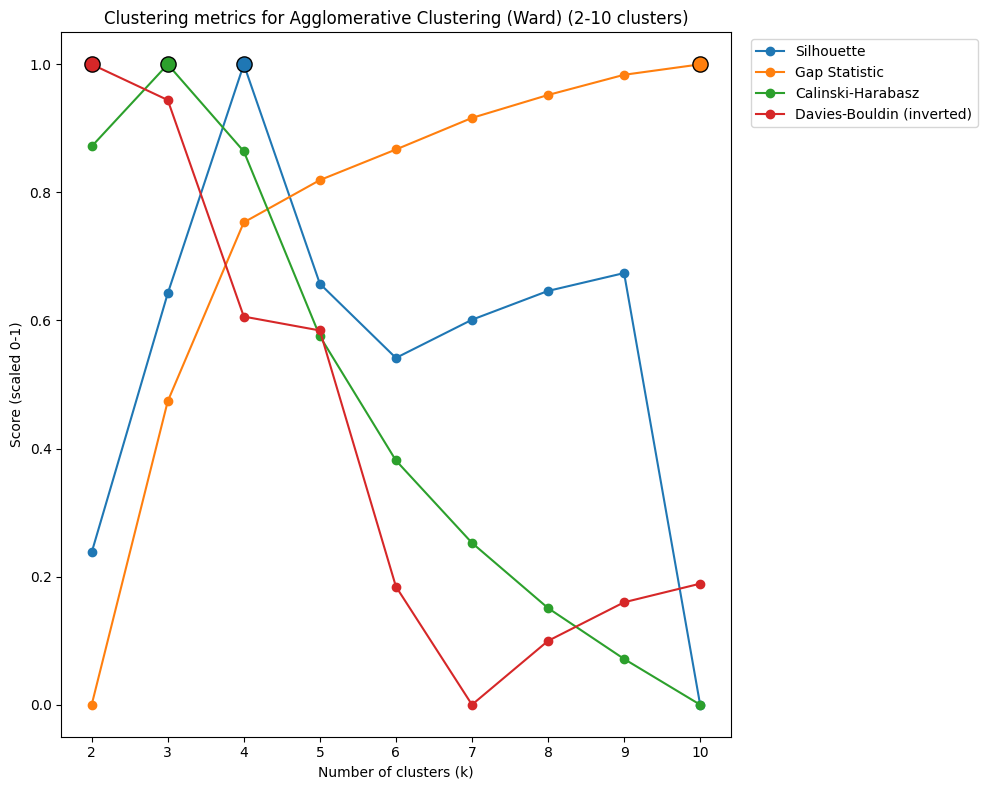

In [26]:
# Prepare storage for metrics
ks = np.arange(2, 11)
silhouette_scores = []
gap_scores = []
calinski_scores = []
davies_scores = []

for k in ks:
    # kmeans = KMeans(n_clusters=k, random_state=RADNDOM_SEED)
    # labels = kmeans.fit_predict(X_pca_50)
    
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_pca_50)
    
    # Silhouette
    sil = silhouette_score(X_pca_50, labels)
    silhouette_scores.append(sil)
    
    # Gap Statistic
    gap = gap_statistic(X_pca_50, labels, n_refs=10, algorithm=KMeans, random_state=RADNDOM_SEED)
    gap_scores.append(gap)
    
    # Calinski-Harabasz (scaled)
    ch = calinski_harabasz_score(X_pca_50, labels)
    calinski_scores.append(ch)
    
    # Davies-Bouldin (inverted)
    db = davies_bouldin_inv(X_pca_50, labels)
    davies_scores.append(db)

# Scale all scores to [0, 1]
scaler = MinMaxScaler()
silhouette_scores_scaled = scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten()
gap_scores_scaled = scaler.fit_transform(np.array(gap_scores).reshape(-1, 1)).flatten()
calinski_scores_scaled = scaler.fit_transform(np.array(calinski_scores).reshape(-1, 1)).flatten()
davies_scores_scaled = scaler.fit_transform(np.array(davies_scores).reshape(-1, 1)).flatten()

# Find maxima for each metric
max_sil_idx = np.argmax(silhouette_scores_scaled)
max_gap_idx = np.argmax(gap_scores_scaled)
max_ch_idx = np.argmax(calinski_scores_scaled)
max_db_idx = np.argmax(davies_scores_scaled)

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_scaled, label='Silhouette', marker='o')
plt.plot(ks, gap_scores_scaled, label='Gap Statistic', marker='o')
plt.plot(ks, calinski_scores_scaled, label='Calinski-Harabasz', marker='o')
plt.plot(ks, davies_scores_scaled, label='Davies-Bouldin (inverted)', marker='o')

# Highlight maxima
plt.scatter(ks[max_sil_idx], silhouette_scores_scaled[max_sil_idx], color='C0', s=120, edgecolor='k', zorder=5, label='Silhouette max')
plt.scatter(ks[max_gap_idx], gap_scores_scaled[max_gap_idx], color='C1', s=120, edgecolor='k', zorder=5, label='Gap Statistic max')
plt.scatter(ks[max_ch_idx], calinski_scores_scaled[max_ch_idx], color='C2', s=120, edgecolor='k', zorder=5, label='Calinski-Harabasz max')
plt.scatter(ks[max_db_idx], davies_scores_scaled[max_db_idx], color='C3', s=120, edgecolor='k', zorder=5, label='Davies-Bouldin max')

handles, labels_ = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels_) if "max" not in l]

plt.xlabel('Number of clusters (k)')
plt.ylabel('Score (scaled 0-1)')
plt.title('Clustering metrics for Agglomerative Clustering (Ward) (2-10 clusters)')
plt.legend([h for h, _ in filtered], [l for _, l in filtered], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

## 4. Run CARVE:

In [53]:
ks = np.arange(2, 11)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=RADNDOM_SEED)  # subsampling because pairwise distances computation is expensive: O(n^2 * d)
idx = next(sss.split(np.arange(len(y_true)), y_true))[1]
dists = pairwise_distances(X_pca_50[idx], metric='sqeuclidean')
median_dist = np.median(dists)
gamma = 1.0 / (2 * median_dist ** 2)

model_grids = [
    (KMeans, {"n_clusters": ks}), 
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "complete", "single"]}), 
    # (SpectralClustering, {"n_clusters": ks, "gamma": [gamma]})
]

cfg = ValidatorConfig(
    X=X_pca_50,
    model_grids=model_grids
)

val = CARVE(cfg)
val.validate(random_state=RADNDOM_SEED)

Grid configs:   0%|          | 0/36 [00:00<?, ?it/s]

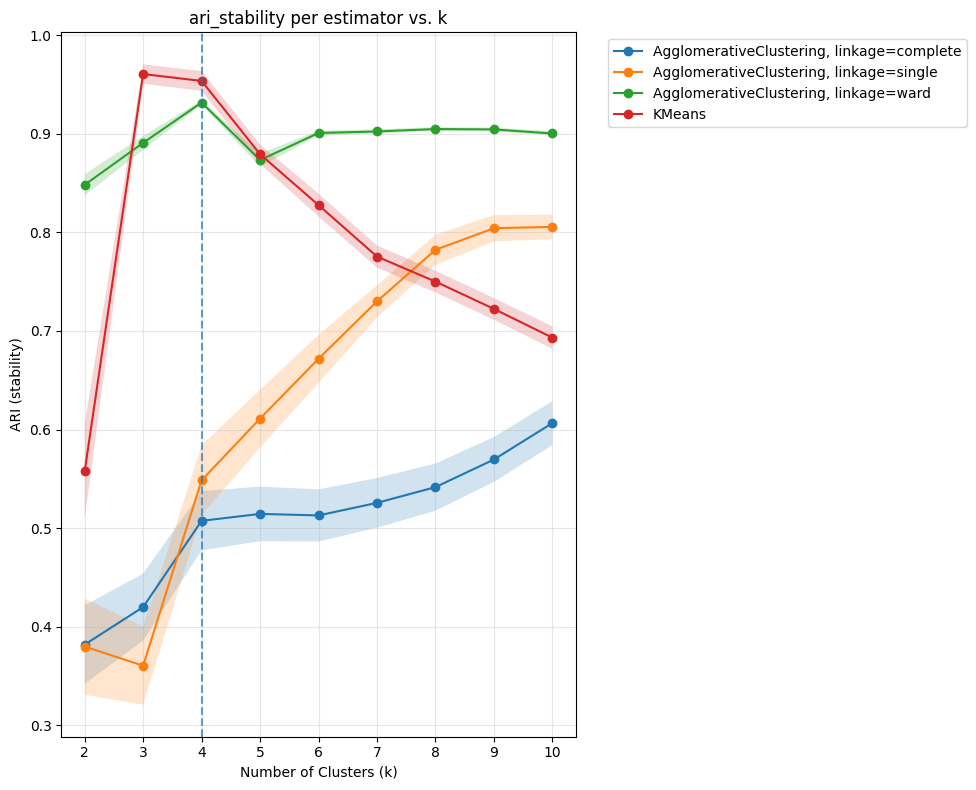

In [61]:
val.plot_results(measure='ari_stability', rule='1se', interactive=False)

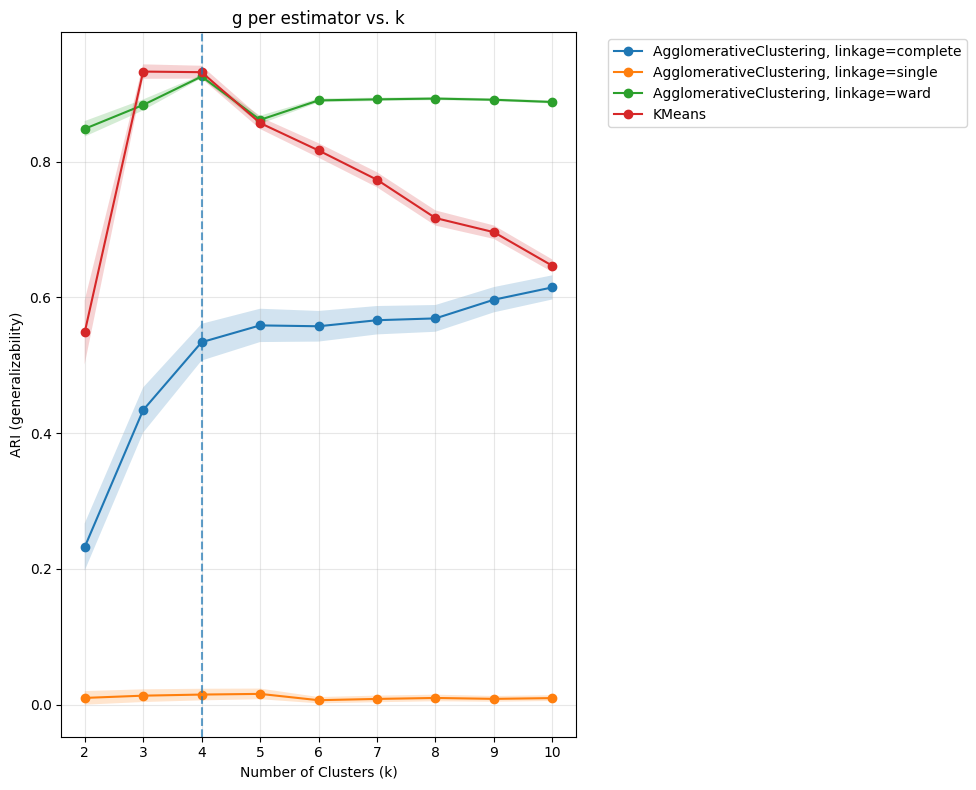

In [62]:
val.plot_results(measure='g', rule='1se', interactive=False)

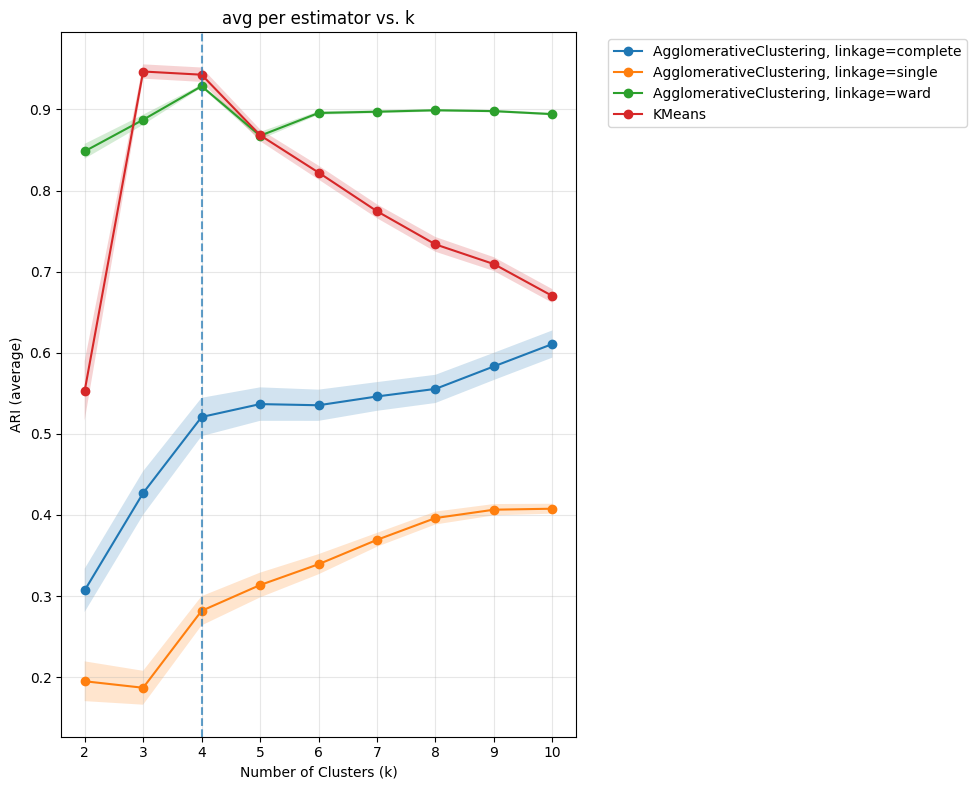

In [63]:
val.plot_results(measure='avg', rule='1se', interactive=False)

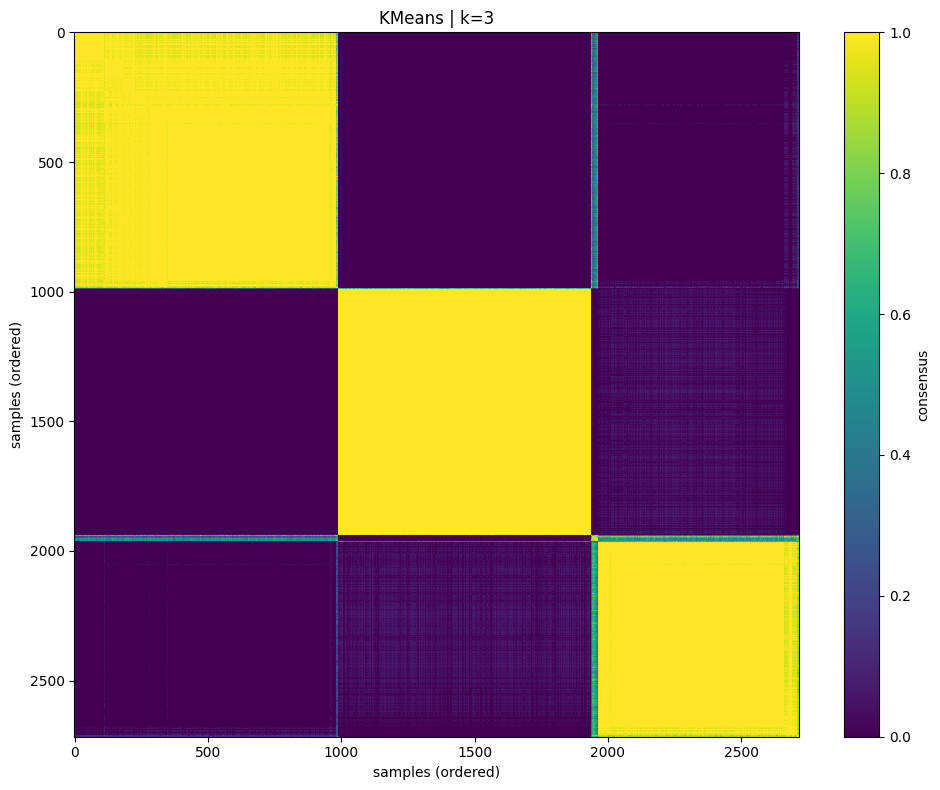

In [64]:
val.plot_consensus_matrix()

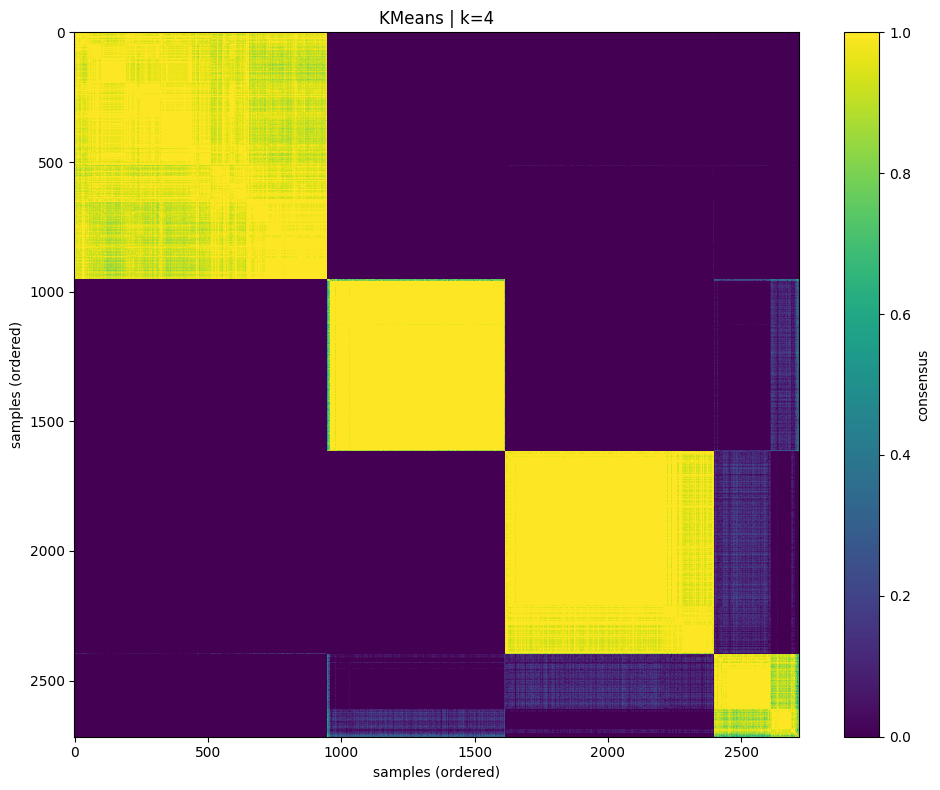

In [65]:
val.plot_consensus_matrix(rule='1se')

In [66]:
val.plot_clustering(rule='1se', interactive=True)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAABAXEAAAAAAAAAAAAAAAAAAAP' ... 'Anb47W7j8PqELVaG7uPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '783, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.9058102760328814,
                         'size': {'bdata': ('MgrocHrPJ0AkAgPl+q4pQIOB3f0cSS' ... '8MK9irKUCyOW10gocpQDJZzZnKsClA'),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '21e52fee-1371-47b1-8525-5607b87b952a',
              'x': {'bdata': ('jqYgQHM1UkAiPgtAD9hgQPeih0Aaxl' ... 'f6QDenEkHnDMFAtCH4QHKSvkCWMaRA'),
  

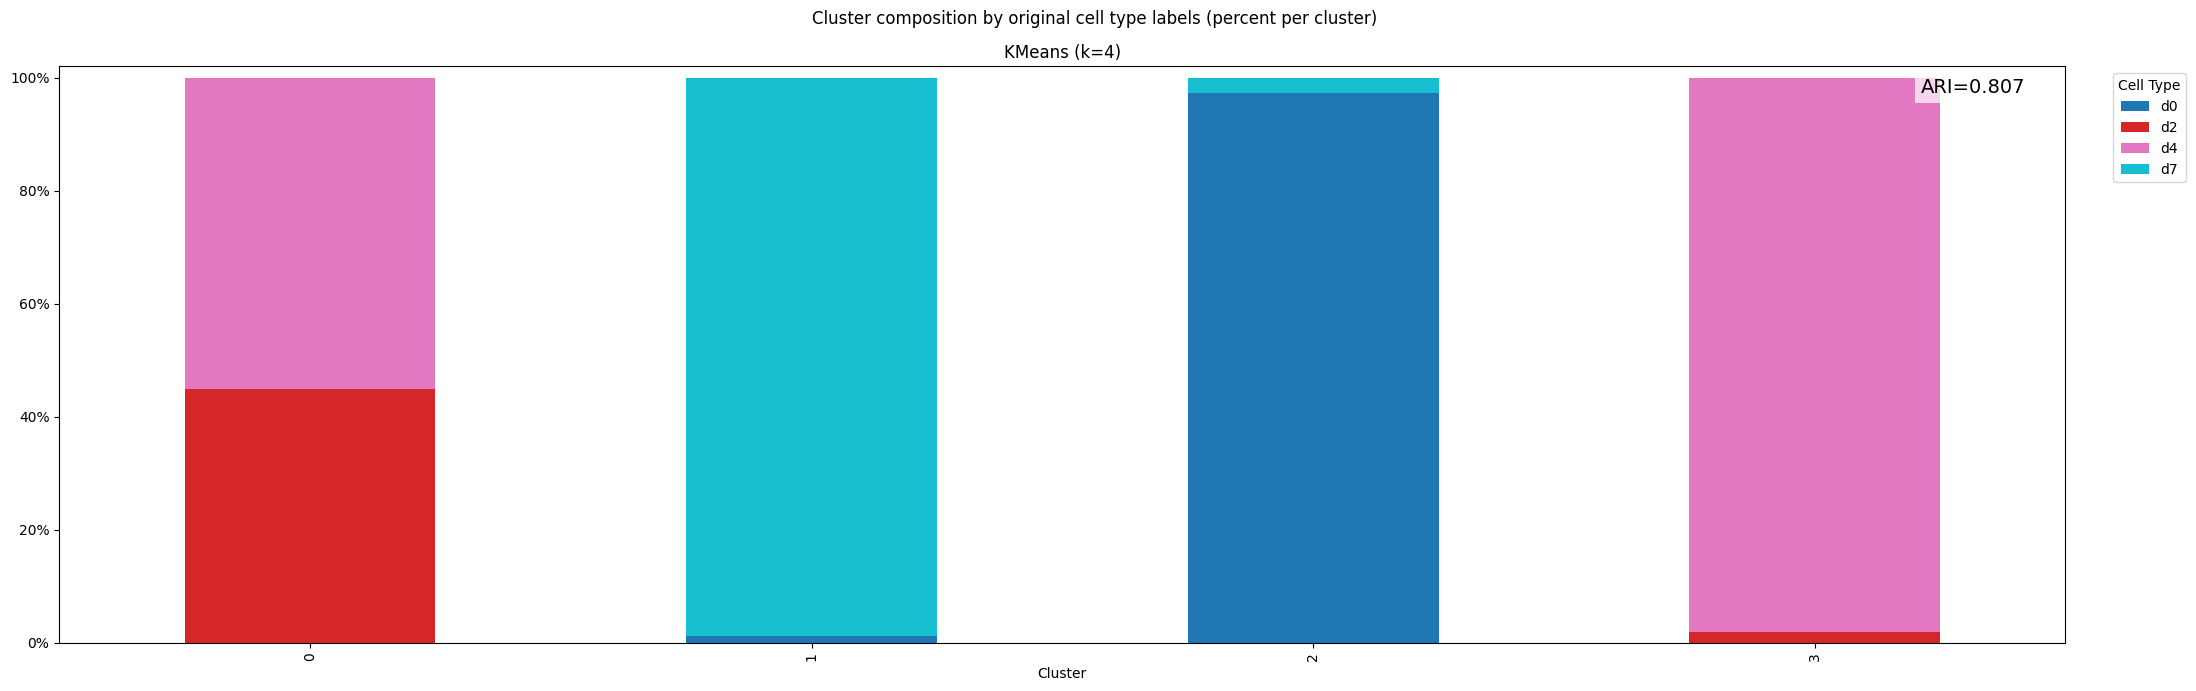

In [69]:
def cluster_composition_percent(labels, y, categories):
    comp = []
    for i in range(len(np.unique(labels))):
        idx = np.where(labels == i)[0]
        counts = Counter(y[idx])
        total = sum(counts.get(cat, 0) for cat in categories)
        comp.append([counts.get(cat, 0) / total if total > 0 else 0 for cat in categories])
    return pd.DataFrame(comp, columns=categories)

fig, axes = plt.subplots(1, 1, figsize=(22, 7), sharey=True)
categories = y.categories

# KMeans k=4
kmeans4 = KMeans(n_clusters=4, random_state=RADNDOM_SEED)
labels_kmeans4 = kmeans4.fit_predict(X_pca_50)
df_kmeans4 = cluster_composition_percent(labels_kmeans4, y, categories)
df_kmeans4.plot(kind='bar', stacked=True, ax=axes, colormap='tab10', legend=False)
axes.set_title('KMeans (k=4)')
axes.set_ylim(0, 1.02)
axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

axes.set_xlabel('Cluster')
axes.legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# Show ARI scores
ari_kmeans4 = adjusted_rand_score(y, labels_kmeans4)
axes.text(0.98, 0.98, f"ARI={ari_kmeans4:.3f}", ha='right', va='top', transform=axes.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.suptitle('Cluster composition by original cell type labels (percent per cluster)')
plt.tight_layout()
plt.show()

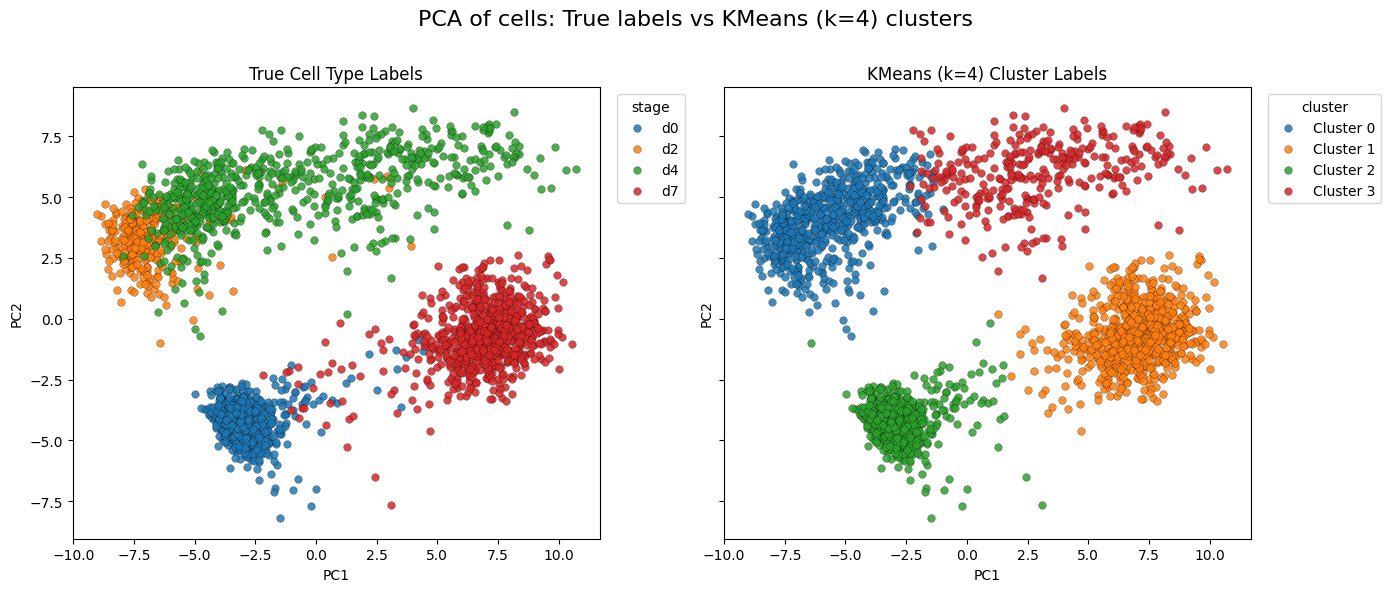

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: True labels
labels_true = pd.Categorical(y).categories
cmap = plt.get_cmap('tab10')
color_map_true = {lab: cmap(i % 10) for i, lab in enumerate(labels_true)}
for lab in labels_true:
    sel = pc_df['label'] == lab
    axes[0].scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=lab, color=color_map_true[lab], s=30, alpha=0.85, edgecolor='k', linewidth=0.2)
axes[0].set_title("True Cell Type Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')

# Right: KMeans (k=4) labels
unique_clusters = np.unique(labels_kmeans4)
cmap2 = plt.get_cmap('tab10')
color_map_kmeans = {cl: cmap2(i % 10) for i, cl in enumerate(unique_clusters)}
for cl in unique_clusters:
    sel = labels_kmeans4 == cl
    axes[1].scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=f"Cluster {cl}", color=color_map_kmeans[cl], s=30, alpha=0.85, edgecolor='k', linewidth=0.2)
axes[1].set_title("KMeans (k=4) Cluster Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle("PCA of cells: True labels vs KMeans (k=4) clusters", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---